# Bienvenidos a Pandas

In [1]:
import pandas as pd

In [2]:
data = {
    'manzanas' : [3, 2, 1, 0],
    'naranjas' : [0, 1, 2, 3],
    'kiwis' : [0, 1, 5, 8]
}

In [3]:
df = pd.DataFrame(data)
df

,manzanas,naranjas,kiwis
0,3,0,0
1,2,1,1
2,1,2,5
3,0,3,8


In [4]:
manzanas = df['manzanas']
manzanas

0    3
1    2
2    1
3    0
Name: manzanas, dtype: int64

In [5]:
df.naranjas

0    0
1    1
2    2
3    3
Name: naranjas, dtype: int64

In [6]:
list(df.naranjas)

[0, 1, 2, 3]

# Análisis del .csv

In [7]:
df = pd.read_csv('data/imdb.csv')

In [8]:
df.head(5)

,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,757074,333.13,76.0
1,2,Prometheus,"Adventure,Mystery,Sci-Fi","Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.46,65.0
2,3,Split,"Horror,Thriller",Three girls are kidnapped by a man with a diag...,M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.3,157606,138.12,62.0
3,4,Sing,"Animation,Comedy,Family","In a city of humanoid animals, a hustling thea...",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.2,60545,270.32,59.0
4,5,Suicide Squad,"Action,Adventure,Fantasy",A secret government agency recruits some of th...,David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.2,393727,325.02,40.0


In [9]:
df.rename(columns= {'Revenue (Millions)' : 'Revenue_Millions'}, inplace=True)
df.columns

Index(['Rank', 'Title', 'Genre', 'Description', 'Director', 'Actors', 'Year',
       'Runtime (Minutes)', 'Rating', 'Votes', 'Revenue_Millions',
       'Metascore'],
      dtype='str')

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rank               1000 non-null   int64  
 1   Title              1000 non-null   str    
 2   Genre              1000 non-null   str    
 3   Description        1000 non-null   str    
 4   Director           1000 non-null   str    
 5   Actors             1000 non-null   str    
 6   Year               1000 non-null   int64  
 7   Runtime (Minutes)  1000 non-null   int64  
 8   Rating             1000 non-null   float64
 9   Votes              1000 non-null   int64  
 10  Revenue_Millions   872 non-null    float64
 11  Metascore          936 non-null    float64
dtypes: float64(3), int64(4), str(5)
memory usage: 93.9 KB


In [11]:
df.Revenue_Millions.isna().any()

np.True_

In [12]:
df.Metascore.isna().any()

np.True_

In [13]:
print("No. de NA en Metascore:", df.Metascore.isna().sum())

No. de NA en Metascore: 64


In [14]:
ratings = df.Rating
type(ratings)

ratings.mean()

np.float64(6.723199999999999)

In [15]:
import numpy as np
np.mean(ratings)

np.float64(6.723199999999999)

# Filtro

In [16]:
df['Rating'].unique

<bound method Series.unique of 0      8.1
1      7.0
2      7.3
3      7.2
4      6.2
      ... 
995    6.2
996    5.5
997    6.2
998    5.6
999    5.3
Name: Rating, Length: 1000, dtype: float64>

In [17]:
np.sort(df['Rating'].unique())

array([1.9, 2.7, 3.2, 3.5, 3.7, 3.9, 4. , 4.1, 4.2, 4.3, 4.4, 4.5, 4.6,
       4.7, 4.8, 4.9, 5. , 5.1, 5.2, 5.3, 5.4, 5.5, 5.6, 5.7, 5.8, 5.9,
       6. , 6.1, 6.2, 6.3, 6.4, 6.5, 6.6, 6.7, 6.8, 6.9, 7. , 7.1, 7.2,
       7.3, 7.4, 7.5, 7.6, 7.7, 7.8, 7.9, 8. , 8.1, 8.2, 8.3, 8.4, 8.5,
       8.6, 8.8, 9. ])

In [18]:
df[df.Rating > 8.0].tail()

,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue_Millions,Metascore
742,743,El secreto de sus ojos,"Drama,Mystery,Romance",A retired legal counselor writes a novel hopin...,Juan José Campanella,"Ricardo Darín, Soledad Villamil, Pablo Rago,Ca...",2009,129,8.2,144524,20.17,80.0
765,766,PK,"Comedy,Drama,Romance",A stranger in the city asks questions no one h...,Rajkumar Hirani,"Aamir Khan, Anushka Sharma, Sanjay Dutt,Boman ...",2014,153,8.2,103279,10.57,51.0
772,773,How to Train Your Dragon,"Animation,Action,Adventure",A hapless young Viking who aspires to hunt dra...,Dean DeBlois,"Jay Baruchel, Gerard Butler,Christopher Mintz-...",2010,98,8.1,523893,217.39,74.0
861,862,Koe no katachi,"Animation,Drama,Romance","The story revolves around Nishimiya Shoko, a g...",Naoko Yamada,"Miyu Irino, Saori Hayami, Aoi Yuki, Kenshô Ono",2016,129,8.4,2421,NaN,80.0
991,992,Taare Zameen Par,"Drama,Family,Music",An eight-year-old boy is thought to be a lazy ...,Aamir Khan,"Darsheel Safary, Aamir Khan, Tanay Chheda, Sac...",2007,165,8.5,102697,1.20,42.0


In [19]:
df.Rating.value_counts()

Rating
7.1    52
6.7    48
7.0    46
6.3    44
7.3    42
7.2    42
6.6    42
7.8    40
6.5    40
6.2    37
6.8    37
6.4    35
7.5    35
7.4    33
6.1    31
6.9    31
7.7    27
7.6    27
8.1    26
5.8    26
6.0    26
7.9    23
5.7    21
8.0    19
5.9    19
5.6    17
5.5    14
5.3    12
5.4    12
5.2    11
8.2    10
8.3     7
4.9     7
4.7     6
8.5     6
5.1     5
4.6     5
8.4     4
4.8     4
5.0     4
4.3     4
8.6     3
3.9     3
2.7     2
3.7     2
8.8     2
4.2     2
3.5     2
9.0     1
4.1     1
4.0     1
3.2     1
4.5     1
1.9     1
4.4     1
Name: count, dtype: int64

In [20]:
counts = df.Rating.value_counts()

counts.index

Index([7.1, 6.7, 7.0, 6.3, 7.3, 7.2, 6.6, 7.8, 6.5, 6.2, 6.8, 6.4, 7.5, 7.4,
       6.1, 6.9, 7.7, 7.6, 8.1, 5.8, 6.0, 7.9, 5.7, 8.0, 5.9, 5.6, 5.5, 5.3,
       5.4, 5.2, 8.2, 8.3, 4.9, 4.7, 8.5, 5.1, 4.6, 8.4, 4.8, 5.0, 4.3, 8.6,
       3.9, 2.7, 3.7, 8.8, 4.2, 3.5, 9.0, 4.1, 4.0, 3.2, 4.5, 1.9, 4.4],
      dtype='float64', name='Rating')

In [21]:
counts.values

array([52, 48, 46, 44, 42, 42, 42, 40, 40, 37, 37, 35, 35, 33, 31, 31, 27,
       27, 26, 26, 26, 23, 21, 19, 19, 17, 14, 12, 12, 11, 10,  7,  7,  6,
        6,  5,  5,  4,  4,  4,  4,  3,  3,  2,  2,  2,  2,  2,  1,  1,  1,
        1,  1,  1,  1])

In [22]:
counts_df = pd.DataFrame({'calif': counts.index, 'frequency': counts.values})
counts_df.head(4)

,calif,frequency
0,7.1,52
1,6.7,48
2,7.0,46
3,6.3,44


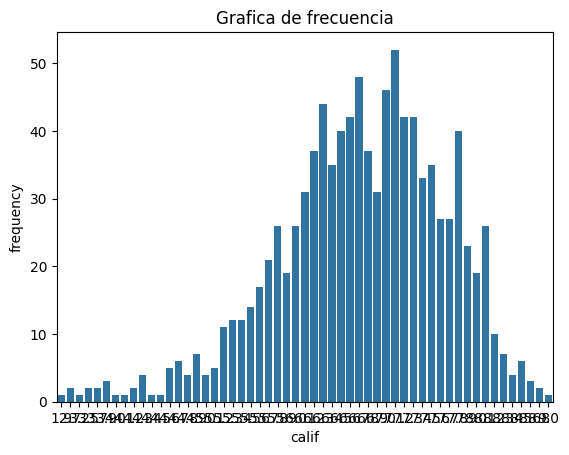

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    x='calif', 
    y='frequency', 
    data=counts_df)

plt.title("Grafica de frecuencia")
plt.show()